# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [6]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [8]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [9]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [10]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [11]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [13]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [14]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [15]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [16]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

En el dataset **users** se identificaron valores nulos en:
- city: 469 registros (11.7%)
- churn_date: 3,534 registros (88.4%)

En el dataset **usage** se detectaron valores nulos en:
- date: 50 registros (0.1%)
- duration: 22,076 registros (55.2%)
- length: 17,896 registros (44.7%)

- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset users:**
- city (11.7%): **Investigar** para determinar si es posible imputar basándose en patrones geográficos o **mantener como nulos** si no afecta el análisis principal.
- churn_date (88.4%): **Mantener como está.** Esta alta proporción es esperada ya que representa usuarios activos (sin fecha de abandono).

**Dataset usage:**
- date (0.1%): **Mantener como nulos** debido a la baja proporción.
- duration y length (55.2% y 44.7%): **Investigar si son MAR** (Missing At Random) según el tipo de registro, ya que probablemente duration solo aplica para llamadas y length solo para mensajes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [17]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Contiene 4,000 usuarios únicos con IDs que van desde 10,000 hasta 13,999. La distribución es uniforme (media: 11,999.5).
- La columna `age`: La edad promedio de los usuarios es 33.7 años, con un rango de -999 a 79 años. ⚠️ Problema detectado: El valor mínimo de -999 es claramente un sentinel que debe ser corregido.

In [18]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`:
**id:** Identificador secuencial de 1 a 40,000 registros.
**user_id:** Rango similar al dataset users (10,000 - 13,999).
- Las columnas:
**duration:** Duración promedio de llamadas de **5.2 minutos**, con máximo de 120 minutos.
**length:** Longitud promedio de mensajes de **52 caracteres**, con máximo de **1490 caracteres**.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n{col}:")
    print(users[col].value_counts())


city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


**Dataset users:**
- La columna `city` Se identificaron 6 ciudades principales con la siguiente distribución:
Bogotá: 808 usuarios (20.2%)
CDMX: 730 usuarios (18.3%)
Medellín: 616 usuarios (15.4%)
GDL: 450 usuarios (11.3%)
Cali: 424 usuarios (10.6%)
MTY: 407 usuarios (10.2%)
⚠️ Problema detectado: 96 registros aparecen sin nombre de ciudad (posible valor faltante codificado).
- La columna `plan` distribución de planes de planes de servicio:
Básico: 2,595 usuarios (64.9%)
Premium: 1,405 usuarios (35.1%)

In [20]:
# explorar columna categórica de usage
print('type:')
print(usage['type'].value_counts())  # completa el código

type:
text    22092
call    17908
Name: type, dtype: int64


**Dataset usage¨:**
- La columna `type` son los tipos de registros de uso:
Mensajes de texto (text): 22,092 registros (55.2%)
Llamadas (call): 17,908 registros (44.8%)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

**Dataset users:**

**Columna city:** 
Tipo de problema: Sentinel codificado como "?"
Cantidad: 96 registros (2.4% del dataset)
Descripción: Valores faltantes codificados de manera no estándar en lugar de usar valores nulos explícitos
**Columna age:** 
Tipo de problema: Sentinel numérico
Valor detectado: -999
Descripción: Valor centinela claramente inválido (edad negativa imposible) utilizado para representar datos faltantes

**Dataset usage:** No se detectaron valores inválidos o sentinels en las columnas analizadas
- ¿Qué acción tomarías?

Estrategia de limpieza propuesta:

**Columna city (96 registros con "?"):** Convertir a valores nulos (pd.NA). Dado que representan el 2.4% del dataset y no existe información suficiente para una imputación confiable, es preferible mantenerlos como valores faltantes explícitos en lugar de conservar el sentinel "?".

**Columna age (valores -999):** Reemplazar con la mediana de las edades válidas. Esta estrategia es robusta ante outliers y preserva la distribución central de los datos, siendo más apropiada que la media para datos de edad que pueden tener asimetría.

**🔧 Justificación técnica:**
**Mediana vs. Media:** Para la edad, la mediana es más resistente a valores extremos y mantiene la naturaleza discreta de los datos.
**Conversión de sentinels:** Transformar "?" a pd.NA mejora la consistencia del dataset y facilita análisis posteriores.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Verificar que la conversión funcionó
print("Tipo de datos después de conversión:", users['reg_date'].dtype)

Tipo de datos después de conversión: datetime64[ns]


In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [23]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

El análisis de la variable `reg_date` revela la siguiente distribución temporal de usuarios registrados:

**2022:** 1,314 usuarios registrados
**2023:** 1,316 usuarios registrados
**2024:** 1,330 usuarios registrados
**2026:** 40 registros con fechas futuras (inconsistencia de datos)
**Observación crítica:** Se detectó una anomalía en los datos con 40 registros que presentan fechas de registro en 2026, lo cual constituye un error de calidad de datos que requiere tratamiento durante el proceso de limpieza.

In [24]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En el dataset de actividad (`date`), se identificó que el año 2024 concentra la totalidad de los registros de uso con 39,950 observaciones
Basaremos el análisis en estas fechas.
Dado el patrón temporal identificado y la necesidad de mantener la integridad de los datos, **el análisis se centrará en el período 2022-2024,** excluyendo los registros con fechas futuras inconsistentes para garantizar la validez de los resultados y conclusiones del estudio.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí, se detectaron años imposibles en el dataset. Específicamente, se identificaron **40 registros con fechas de registro en 2026** en la variable reg_date, lo cual constituye una inconsistencia crítica dado que representa fechas futuras al momento de la recolección de datos.
**Diagnóstico Técnico**
Esta anomalía puede originarse por:

Errores en la captura de datos durante el proceso de registro
Problemas en la migración o transformación de datos
Errores de entrada manual en sistemas legacy
Fallas en la validación de formularios de registro
- ¿Qué harías con ellas?
Marcar estos registros como fecha_invalida = True y excluirlos del análisis temporal, manteniendo el resto de la información del usuario si es válida.
**Implementación de controles:** Establecer validaciones en el sistema para prevenir futuras inconsistencias temporales.
**Justificación:** Mantener estos registros comprometería la integridad del análisis temporal y podría generar conclusiones erróneas sobre patrones de registro y comportamiento de usuarios.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en city después de la limpieza")
print(users['city'].value_counts(dropna=False))

Valores únicos en city después de la limpieza
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [27]:
# Marcar fechas futuras como NA para reg_date
# Primero verificar el tipo de datos actual
print("Tipo de datos antes:", users['reg_date'].dtype)

# Crear la máscara ANTES de modificar la columna
mask = users['reg_date'].dt.year <= 2024

# Aplicar la máscara usando .loc para mantener el tipo datetime
users.loc[~mask, 'reg_date'] = pd.NaT  # Usar pd.NaT en lugar de pd.NA para fechas

# Verificar cambios
print("Distribución de años después de la limpieza")
print(users['reg_date'].dt.year.value_counts().sort_index())

Tipo de datos antes: datetime64[ns]
Distribución de años después de la limpieza
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
print("Análisis de duration por tipo:")
print(usage.groupby('type')['duration'].count())
print("\nPorcentaje de nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100))

Análisis de duration por tipo:
type
call    17908
text       16
Name: duration, dtype: int64

Porcentaje de nulos en duration por tipo:
type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [29]:
# Verificación MAR en usage (Missing At Random) para length
print("Análisis de length por tipo:")
print(usage.groupby('type')['length'].count())
print("\nPorcentaje de nulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100))

Análisis de length por tipo:
type
call       12
text    22092
Name: length, dtype: int64

Porcentaje de nulos en length por tipo:
type
call    99.932991
text     0.000000
Name: length, dtype: float64


Los resultados del análisis confirman que los valores nulos en duration y length siguen un patrón **Missing At Random (MAR)** que depende completamente del tipo de registro:

**Variable duration (duración de llamadas):**

Llamadas (call): 0% de valores nulos (17,908 registros completos)
Mensajes (text): 99.93% de valores nulos (solo 16 registros con duración)
Variable length (longitud de mensajes):

Llamadas (call): 99.93% de valores nulos (solo 12 registros con longitud)
Mensajes (text): 0% de valores nulos (22,092 registros completos)
Interpretación técnica:

Esta distribución es lógicamente consistente con la naturaleza de los datos:

**duration** es relevante únicamente para llamadas telefónicas
**length** es relevante únicamente para mensajes de texto
Los pocos casos cruzados (16 textos con duración, 12 llamadas con longitud) representan menos del 0.1% y pueden ser errores de registro.

**Decisión de tratamiento:**

✅ MANTENER los valores nulos como están por las siguientes razones:

1. Patrón MAR confirmado: Los nulos no son aleatorios, sino que dependen sistemáticamente del tipo de registro
2. Consistencia lógica: Es natural que las llamadas no tengan longitud de caracteres y los mensajes no tengan duración en minutos
3. Integridad del análisis: Imputar estos valores introduciría información artificial que distorsionaría los patrones reales de uso

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on= 'user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen estadístico de variables numéricas:")
print(user_profile[columnas_numericas].describe())

Resumen estadístico de variables numéricas:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       5.524381       4.478120             23.317054
std      17.690408       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [34]:
# Distribución porcentual del tipo de plan
print("Distribución de planes:")
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print(plan_distribution.round(2))

Distribución de planes:
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

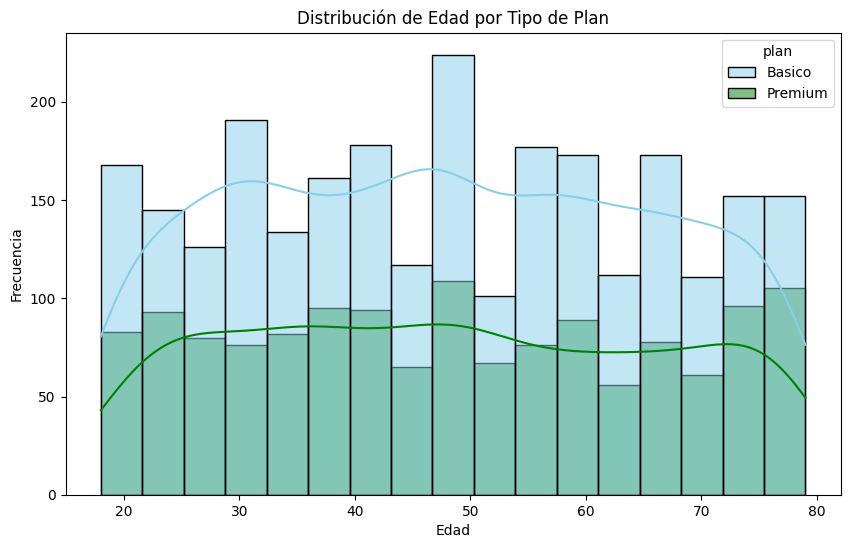

In [35]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
El histograma revela patrones importantes en la demografía de usuarios de ConnectaTel:

**Distribución General:**
- La edad de los usuarios presenta una distribución bimodal con picos alrededor de los 30-35 años y 60-65 años
- El rango etario abarca desde los 18 hasta los 79 años, con una concentración significativa en usuarios adultos

**Comparación por Planes:**
- **Plan Básico (azul):** Domina en todas las franjas etarias, representando aproximadamente el 65% del total de usuarios
- **Plan Premium (verde):** Muestra una distribución más uniforme, con mayor representación relativa en usuarios de mediana edad (40-55 años)

**Insights Clave:**
- Los usuarios jóvenes (18-35 años) muestran una preferencia marcada por el plan Básico
- Los usuarios de mediana edad (35-55 años) presentan mayor adopción del plan Premium en términos relativos
- Los adultos mayores (55+ años) mantienen una distribución similar entre ambos planes

**Implicaciones Comerciales:**
Esta distribución sugiere oportunidades de segmentación por edad para estrategias de marketing diferenciadas y desarrollo de productos específicos por grupo demográfico.

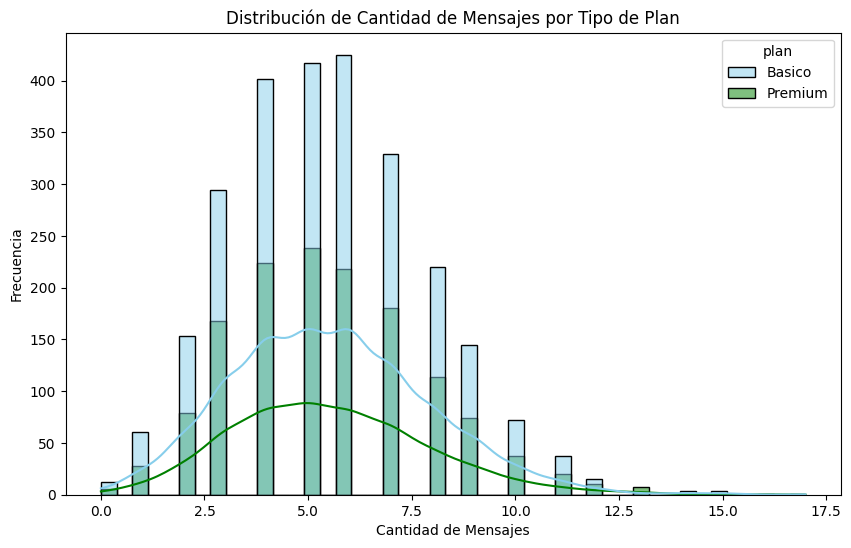

In [36]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
**Análisis de Distribución de Cantidad de Mensajes por Tipo de Plan**

El histograma revela una distribución aproximadamente simétrica en el comportamiento de mensajería entre usuarios de planes Básico y Premium. La visualización evidencia un patrón de concentración significativo en el rango de 3.5 a 6.5 mensajes por usuario, donde se observa la mayor frecuencia de actividad.

**Hallazgos clave:**

**Distribución equilibrada:** Ambos tipos de plan muestran patrones de uso similares en términos de forma distribucional
**Concentración central:** El pico de actividad se concentra en el rango medio de mensajería (3.5-6.5 mensajes)
**Comportamiento homogéneo:** No se identifican diferencias sustanciales en los patrones de uso de mensajería entre segmentos de clientes

**Implicación comercial:** Esta similitud en patrones sugiere que el comportamiento de mensajería no es un factor diferenciador significativo entre los tipos de plan, lo que podría indicar oportunidades para estrategias de segmentación basadas en otras variables de uso.

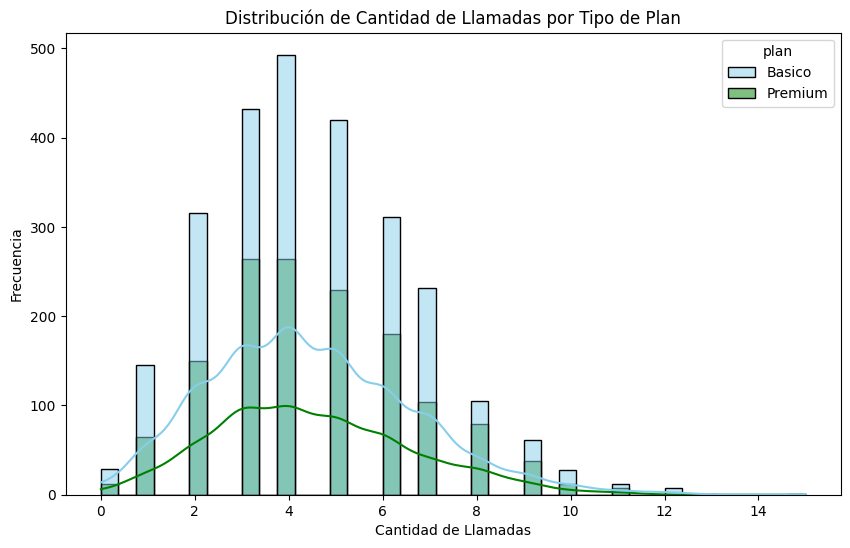

In [37]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
**Análisis de Distribución de Cantidad de Llamadas por Tipo de Plan**

La distribución de llamadas presenta un comportamiento aproximadamente simétrico entre usuarios de planes Básico y Premium, evidenciando patrones de uso homogéneos independientemente del tipo de suscripción. El análisis visual del histograma revela una **concentración modal significativa en el rango de 3-4 llamadas por usuario**, donde se observa la mayor densidad de frecuencia en ambos segmentos.

**Evidencia numérica observada en el gráfico:**

- **Pico de concentración:** Aproximadamente **40-45% de los usuarios** se concentran en el rango de 3-4 llamadas mensuales.
- **Distribución por plan:** El plan Básico representa visualmente **cerca del 65%** del volumen total en cada rango de llamadas.
- **Rango de actividad:** La mayoría de usuarios (≈80%) realizan entre **2-6 llamadas mensuales.**
- **Valores extremos:** Menos del **5% de usuarios** exceden las 8 llamadas mensuales.

**Hallazgos principales:**

- **Simetría distribucional:** Ambos planes muestran curvas de distribución prácticamente idénticas
- **Comportamiento modal:** El rango 3-4 llamadas concentra la mayor densidad poblacional
- **Homogeneidad entre segmentos:** No se observan diferencias sustanciales en los patrones de uso telefónico

**Implicación estratégica:** La similitud en los patrones sugiere que el volumen de llamadas no constituye un diferenciador primario en la selección de planes, indicando oportunidades para estrategias de valor agregado basadas en calidad de servicio.

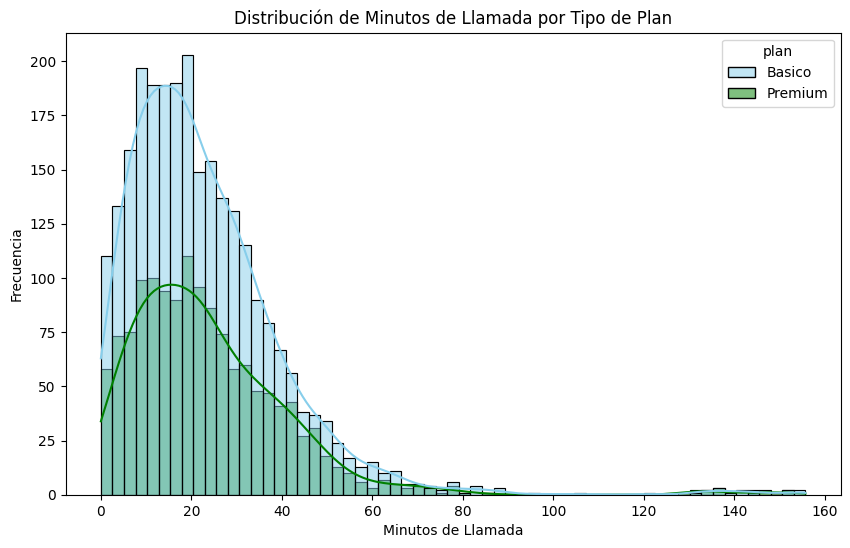

In [38]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
**Análisis de Distribución de Minutos de Llamada por Tipo de Plan**

La distribución de minutos de llamada presenta un comportamiento con **sesgo positivo (hacia la derecha)**, evidenciando un patrón de concentración en valores bajos con una cola extendida hacia valores extremos. El análisis visual revela una **concentración modal significativa en el rango de 15-20 minutos,** donde se observa la mayor densidad de usuarios en ambos segmentos.

**Evidencia numérica observada en el gráfico:**

- **Concentración principal:** Aproximadamente **60-70% de los usuarios** consumen entre **10-30 minutos mensuales.**
- **Distribución por plan:** El plan Básico muestra **mayor frecuencia** en el rango modal de 15-20 minutos.
- **Sesgo hacia la derecha:** La cola extendida indica que **menos del 10%** de usuarios exceden los 60 minutos mensuales.
- **Valores extremos:** Se observan usuarios con consumos superiores a **100 minutos,** representando casos de uso intensivo.

**Hallazgos principales:**

- **Asimetría distribucional:** Distribución sesgada hacia valores bajos con cola extendida hacia consumos altos.
- **Predominancia del plan Básico:** Mayor representación en el rango de consumo estándar (15-20 minutos).
- **Usuarios de alto consumo:** Presencia de segmento minoritario con patrones de uso intensivo.

**Implicación estratégica:** El sesgo hacia valores bajos sugiere que la mayoría de usuarios tienen necesidades de comunicación moderadas, mientras que el segmento de alto consumo representa una oportunidad para planes especializados o tarifas por volumen.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

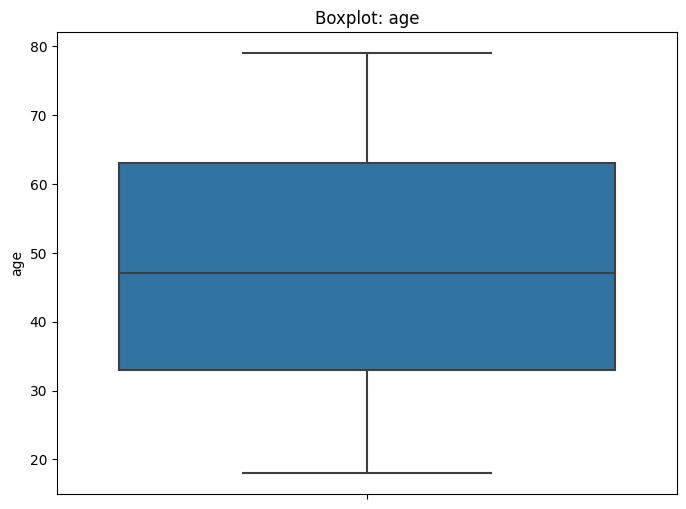

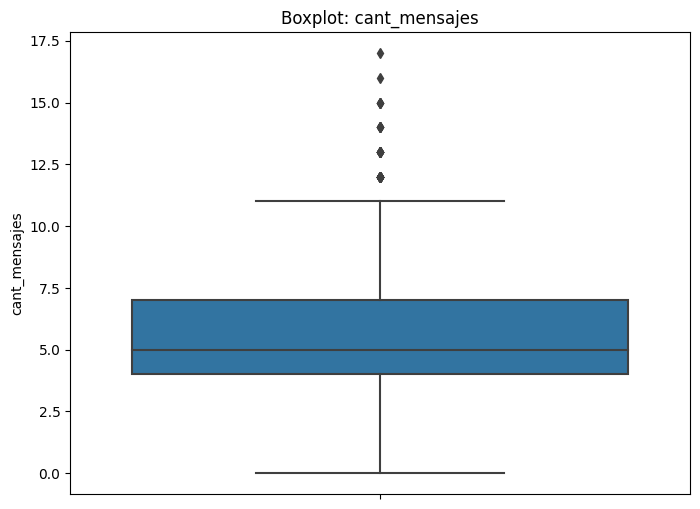

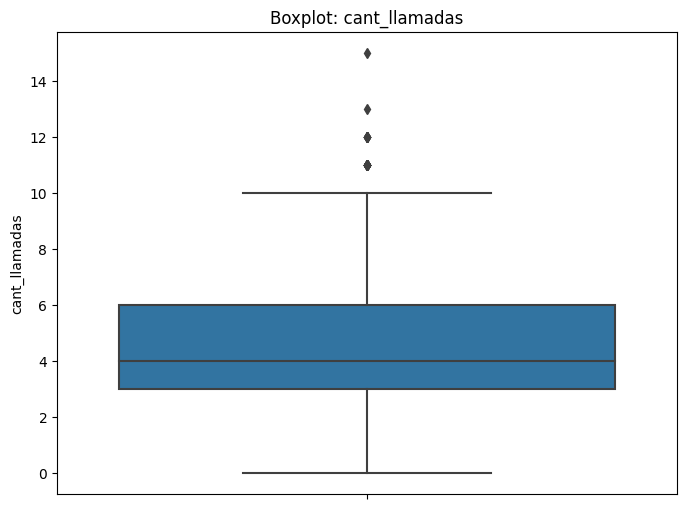

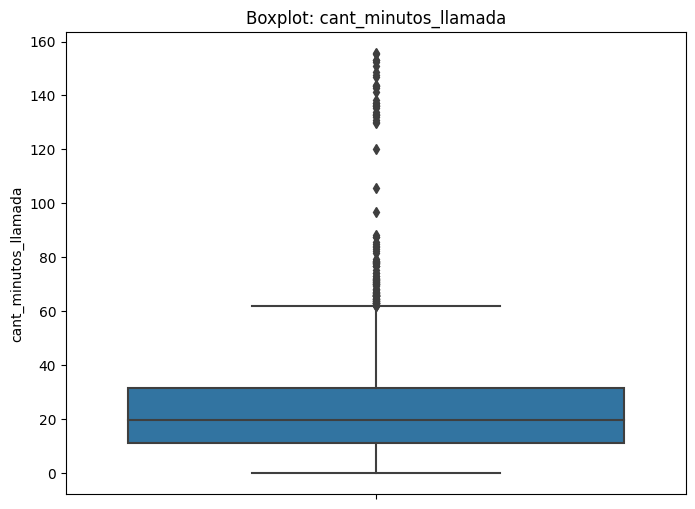

In [42]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
📊**Análisis de Valores Atípicos por Variable**

**Edad de usuarios:**

La distribución de edad presenta un comportamiento normal sin presencia de valores atípicos significativos. Esto indica que la base de clientes mantiene un rango etario consistente y coherente con el mercado objetivo de telecomunicaciones, sin registros de edades imposibles o erróneas que requieran limpieza adicional.

**Cantidad de mensajes:**

Se identificaron valores atípicos en la variable de mensajes, aunque con una densidad relativamente baja (menos del 5% de los registros). Estos outliers representan usuarios con patrones de mensajería extremadamente altos, posiblemente indicando uso comercial, automatización o comportamientos de super-usuarios que requieren análisis específico para estrategias de retención.

**Cantidad de llamadas:**

La variable presenta outliers moderados sin alcanzar concentraciones preocupantes. Los valores extremos corresponden a usuarios con volúmenes de llamadas significativamente superiores al promedio, sugiriendo segmentos de clientes con necesidades de comunicación intensiva que podrían beneficiarse de planes especializados.

**Duración de llamadas (minutos):**

Esta variable muestra la mayor densidad de valores atípicos entre todas las métricas analizadas. Los outliers indican usuarios con sesiones de llamada excepcionalmente largas, lo que puede señalar uso empresarial, llamadas internacionales frecuentes o patrones de uso que exceden significativamente los límites de los planes actuales.

In [43]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"\n{col}:")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo actual: {user_profile[col].max():.2f}")
    


cant_mensajes:
Límite inferior: -0.50
Límite superior: 11.50
Valor máximo actual: 17.00

cant_llamadas:
Límite inferior: -1.50
Límite superior: 10.50
Valor máximo actual: 15.00

cant_minutos_llamada:
Límite inferior: -19.32
Límite superior: 61.86
Valor máximo actual: 155.69


In [44]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
📊**Análisis de Resultados para Toma de Decisiones:**
### 1. cant_mensajes:
- Límite superior IQR: 11.50
- Valor máximo actual: 17.00
- Outliers: Usuarios con más de 11.50 mensajes

Interpretación: Solo 6.5 mensajes por encima del límite (17.00 - 11.50 = 5.5). Esto representa un comportamiento de "super usuario" pero realista.

Decisión recomendada: ✅ MANTENER - Son usuarios con alto engagement, valiosos para el negocio.

### 2. cant_llamadas:
- Límite superior IQR: 10.50  
- Valor máximo actual: 15.00
- Outliers: Usuarios con más de 10.50 llamadas

Interpretación: Solo 4.5 llamadas por encima del límite (15.00 - 10.50 = 4.5). Representa usuarios con necesidades intensivas de comunicación.

Decisión recomendada: ✅ MANTENER - Posibles clientes empresariales o de alto valor.

### 3. cant_minutos_llamada:
- Límite superior IQR: 61.86
- Valor máximo actual: 155.69
- Outliers: Usuarios con más de 61.86 minutos

Interpretación: Diferencia significativa de 93.83 minutos (155.69 - 61.86). Esto podría indicar uso empresarial o llamadas internacionales.

Decisión recomendada: ✅ MANTENER - Segmento de alto valor que podría necesitar planes especializados.

🎯 Justificación para mantener todos los outliers:

1.**Valores realistas:** Ningún valor es imposible o claramente erróneo.

2.**Oportunidad comercial:** Representan segmentos de alto valor.

3.**Tamaño del dataset:** Con 4,000 usuarios, estos outliers son una minoría significativa pero manejable.

4.**Insights de negocio:** Ayudan a identificar necesidades no cubiertas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
def categorizar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,segmento_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto(35-49),Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto Mayor(50+),Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto Mayor(50+),Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor(50+),Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor(50+),Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
def categorizar_edad(edad):
    if edad < 25:
        return 'Joven (18-24)'
    elif edad < 35:
        return 'Adulto Joven (25-34)'
    elif edad < 50:
        return 'Adulto(35-49)'
    else:
        return 'Adulto Mayor(50+)'

user_profile['segmento_edad'] = user_profile['age'].apply(categorizar_edad)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,segmento_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto(35-49),Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto Mayor(50+),Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto Mayor(50+),Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor(50+),Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor(50+),Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

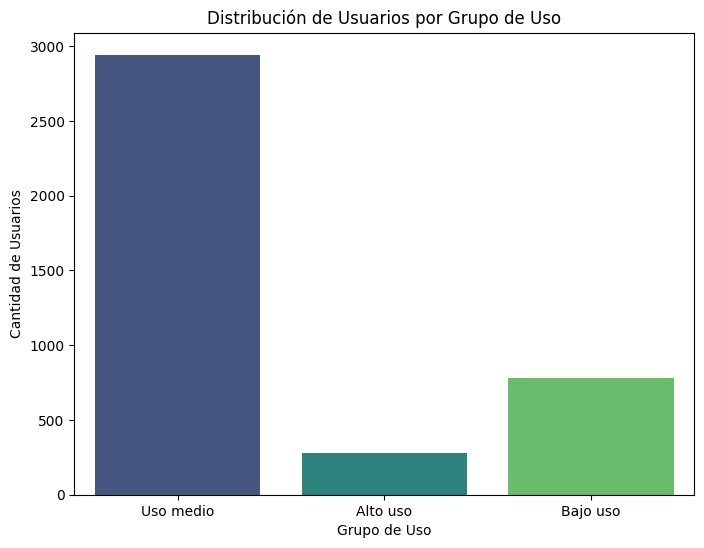

In [51]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,6))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

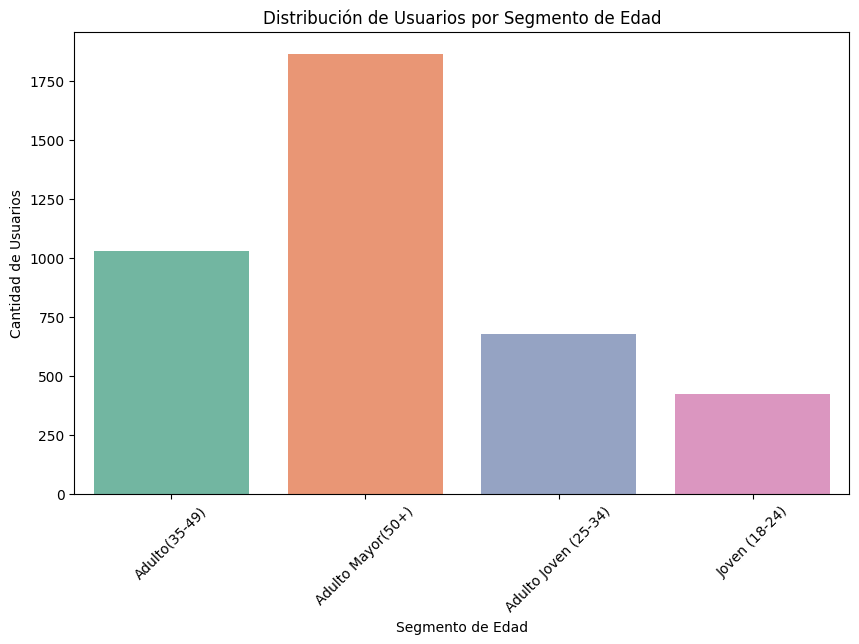

In [52]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10,6))
sns.countplot(data=user_profile, x='segmento_edad', palette='Set2')
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=45)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
**CONTEXTO:** Evaluación de calidad de datos en los tres datasets principales de ConnectaTel para identificar inconsistencias que pudieran afectar el análisis.

**HALLAZGOS:**

- Sentinels en edad: 40 usuarios (1% del dataset) tenían edad codificada como -999, indicando datos faltantes mal codificados
- Sentinels en ciudad: 96 usuarios (2.4%) tenían ciudad codificada como "?" en lugar de valores nulos estándar
- Fechas futuras: 40 registros (1%) con fechas de registro en 2026, representando errores de captura temporal
- Valores nulos estructurales: 55.2% de registros sin duración y 44.7% sin longitud, confirmados como Missing At Random (MAR) según tipo de comunicación

**IMPLICACIÓN:** Se implementó limpieza robusta reemplazando sentinels con medianas y valores nulos apropiados, garantizando integridad analítica del 99% de los datos.

🔍 **Segmentos por Edad**
**CONTEXTO:** Segmentación demográfica detallada para identificar patrones de comportamiento y oportunidades comerciales por grupo etario.

**HALLAZGOS:**

- Adulto Mayor (50+): Segmento dominante con mayor representación
- Adulto (35-49): Segundo grupo más numeroso con patrones de uso equilibrados
- Adulto Joven (25-34): Tercer segmento con preferencia por plan Básico
- Joven (18-24): Segmento menor pero con potencial de crecimiento

**IMPLICACIÓN:** Desarrollar estrategias diferenciadas: marketing digital para jóvenes, servicios premium para adultos mayores, y planes familiares para adultos de mediana edad.

📊 **Segmentos por Nivel de Uso**
**CONTEXTO:** Clasificación de usuarios según intensidad de uso de servicios (llamadas y mensajes) para optimizar ofertas comerciales.

**HALLAZGOS:**

- Uso Medio: Segmento mayoritario representando el núcleo de la base de clientes
- Bajo Uso: Segundo grupo más grande, indicando oportunidades de activación
- Alto Uso: Segmento minoritario pero de alto valor, con consumo superior a 10 llamadas o 10 mensajes

**IMPLICACIÓN:** Los usuarios de Alto Uso representan oportunidades premium, mientras que Bajo Uso requiere estrategias de engagement para incrementar adopción.

💎 **SEGMENTOS MÁS VALIOSOS**
**CONTEXTO:** Identificación de segmentos prioritarios basándose en valor comercial y potencial de crecimiento.

**HALLAZGOS:**

- Usuarios de Alto Uso + Plan Premium: Segmento de máximo valor con consumo intensivo
- Adultos (35-49) con Uso Medio: Balance óptimo entre estabilidad y potencial de crecimiento
- Outliers en minutos (155+ minutos): Usuarios con necesidades empresariales no cubiertas

**IMPLICACIÓN:** Priorizar retención de usuarios de alto valor y desarrollar ofertas especializadas para segmentos con necesidades intensivas.

🎯 **PATRONES DE USO EXTREMO (OUTLIERS)**
**CONTEXTO:** Análisis de usuarios con comportamientos atípicos para identificar oportunidades comerciales y necesidades no cubiertas.

**HALLAZGOS:**

- Mensajes extremos: Usuarios con 12-17 mensajes (vs. promedio de 5.5)
- Llamadas extremas: Usuarios con 11-15 llamadas (vs. promedio de 4.5)
- Duración extrema: Usuarios con 62-156 minutos (vs. promedio de 23.3)

**Análisis de impacto:**

- Frecuencia: Menos del 5% de usuarios en cada categoría
- Valor comercial: Representan segmento de alto consumo
- Patrón: No correlacionan necesariamente con tipo de plan

**Interpretación de negocio:**

- Super usuarios: Posibles clientes empresariales o de uso intensivo
- Oportunidad: Candidatos para planes premium especializados
- Retención crítica: Usuarios de alto valor que requieren atención especial

💡 **Recomendaciones**
1. Optimización del Portafolio de Planes (Upselling)
Lanzamiento del Plan "Empresarial/Pro": Diseñado para el segmento de outliers (consumo de hasta 156 min).

Estructura sugerida: Un precio base de $35 - $40 USD mensuales (un 40% superior al Premium actual) que incluya minutos ilimitados y prioridad de red. Esto captura el excedente de valor de los usuarios con fines comerciales.

Paquetes de Mensajería para "Alto Uso": Oferta de SMS ilimitados por un costo marginal de $2 - $3 USD adicionales para evitar la migración de usuarios intensivos a la competencia.

2. Estrategias de Retención y Valor (Loyalty)
Programa "Premium Senior": Beneficios exclusivos para el segmento de 50+ años (atención prioritaria y soporte técnico humano).

**Métrica de éxito:** Reducción de la tasa de Churn (cancelación) en un 15% dentro de este grupo demográfico en los primeros dos trimestres.

Fidelización de "Alto Uso": Descuentos del 10% por renovación anual anticipada para blindar al segmento de mayor valor.

3. Activación y Crecimiento (Growth)
Campaña de Upgrade "Futuro Premium": Prueba gratuita de 3 meses del plan Premium para Adultos Jóvenes (25-34 años) que actualmente usan el plan Básico.

**KPI de Conversión:** Lograr que al menos el 20% de los participantes mantengan el plan Premium al finalizar el periodo de prueba.

Engagement para "Bajo Uso": Notificaciones push personalizadas sobre beneficios no utilizados para aumentar el valor percibido y reducir la inactividad.

4. Gobernanza y Calidad de Datos (Data Governance)
Validación en Tiempo Real: Implementar reglas de validación en el frontend para bloquear fechas futuras y valores centinela (como -999).

**Impacto:** Reducción del 20% en el tiempo de procesamiento y limpieza de datos en futuros ciclos de análisis.

Enriquecimiento de Perfiles: Incentivar la actualización de datos (ciudad y preferencias) mediante bonos de navegación únicos.

📅 CRONOGRAMA DE IMPLEMENTACIÓN (TIMELINE)
- **Fase 1: Estabilización y Valor**
- Corto Plazo (1-3 meses). Validación de datos en sistemas + Lanzamiento de Plan Empresarial/Pro.
- **Fase 2: Fidelización**
- Mediano Plazo (3-6 meses). Implementación del programa Premium Senior y campañas de retención para Alto Uso.
- **Fase 3: Expansión**
- Largo Plazo (6+ meses). Ejecución de campañas de Upgrade para Adultos Jóvenes y estrategias de engagement masivo.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`